#  Breast Ultrasound Classification (MLOps Summative)

**Task:** binary classification of breast-ultrasound images as **benign** vs **malignant** on the BUSI dataset, extending the Intro-to-ML summative into a deployable, monitorable pipeline.

This notebook covers the offline half of the assignment end-to-end:
1. Data acquisition · 2. Data processing · 3. EDA / feature visualizations ·
4. Model creation · 5. Training · 6. Testing & evaluation · 7. Prediction function · 8. Retraining hook.

The same functions used here live in `src/` and are what the FastAPI service and the retraining endpoint call in production — the notebook and the deployed app share one code path.

## 0 · Environment

In [1]:
import sys, os
sys.path.append('..')          # import the src/ package from notebook/
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_context('notebook'); plt.rcParams['figure.dpi'] = 110
from src import preprocessing as pp
from src import model as M
print('classes:', pp.CLASS_NAMES, '| image size:', pp.IMG_SIZE)

classes: ('benign', 'malignant') | image size: 224


## 1 · Data acquisition

The BUSI dataset (780 images: 437 benign, 210 malignant, 133 normal) is downloaded and organised by `scripts/acquire_data.py`, which keeps only **benign** and **malignant** (the `normal` class is excluded to match the Intro-to-ML report), removes exact-duplicate images, and writes a stratified 80/20 split:

```bash
python scripts/acquire_data.py
```

It produces `data/train/<class>/` and `data/test/<class>/`.

In [2]:
DATA = Path('..') / 'data'
train_dist = pp.class_distribution(DATA / 'train')
test_dist  = pp.class_distribution(DATA / 'test')
print('train:', train_dist)
print('test :', test_dist)

train: {'benign': 350, 'malignant': 167}
test : {'benign': 87, 'malignant': 42}


## 2 · Data processing

**Steps:** (a) list images per class, excluding segmentation `*_mask` files; (b) verify there are no exact-duplicate images (a real BUSI data-quality issue); (c) inspect raw image sizes to justify the resize; (d) grayscale ultrasound is read as 3 channels because ImageNet backbones expect RGB; (e) every image is resized to 224×224 and left in [0,255] — MobileNetV2 rescales to [-1,1] internally.

In [3]:
train_paths, train_labels = pp.list_images(DATA / 'train')
test_paths,  test_labels  = pp.list_images(DATA / 'test')
print(f'{len(train_paths)} train + {len(test_paths)} test images')

dupes = pp.find_duplicates(train_paths + test_paths)
print('exact-duplicate groups remaining:', len(dupes))

stats = pp.image_size_stats(train_paths)
print('raw image size stats:', stats)

517 train + 129 test images


exact-duplicate groups remaining: 0
raw image size stats: {'count': 517, 'min_w': 190, 'max_w': 1048, 'min_h': 324, 'max_h': 719, 'mean_w': 615.0251450676983, 'mean_h': 498.06382978723406}


## 3 · Exploratory data analysis — three feature interpretations

We interpret three features of the data and ask what story each tells.

### Feature 1 · Class balance
*What story does it tell?* The dataset is **imbalanced**: benign images roughly double malignant. A naive model could reach ~68% accuracy by always predicting *benign*. This motivates **class-weighting** the loss and reporting **recall / F1 / ROC-AUC**, not just accuracy.

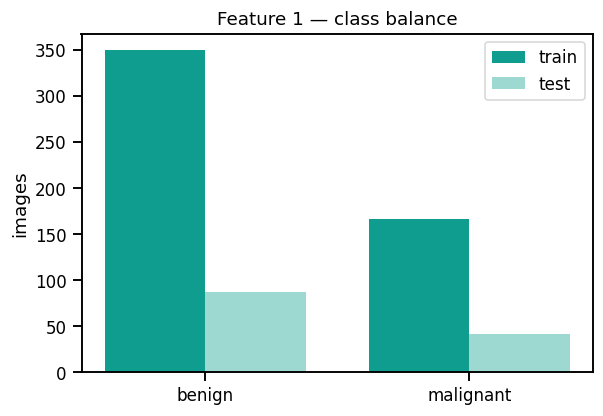

benign:malignant ratio = 2.10:1


In [4]:
fig, ax = plt.subplots(figsize=(6,4))
idx = np.arange(len(pp.CLASS_NAMES)); w = 0.38
ax.bar(idx-w/2, [train_dist[c] for c in pp.CLASS_NAMES], w, label='train', color='#0f9d8f')
ax.bar(idx+w/2, [test_dist[c]  for c in pp.CLASS_NAMES], w, label='test',  color='#9dd8d1')
ax.set_xticks(idx); ax.set_xticklabels(pp.CLASS_NAMES); ax.set_ylabel('images'); ax.legend()
ax.set_title('Feature 1 — class balance'); plt.show()
ratio = train_dist['benign']/max(train_dist['malignant'],1)
print(f'benign:malignant ratio = {ratio:.2f}:1')

### Feature 2 · Mean pixel intensity (echogenicity) by class
*What story does it tell?* Malignant lesions are often **hypoechoic** (darker) on ultrasound. If mean grayscale intensity differs by class, brightness is a genuine signal the CNN can use — not just lesion shape.

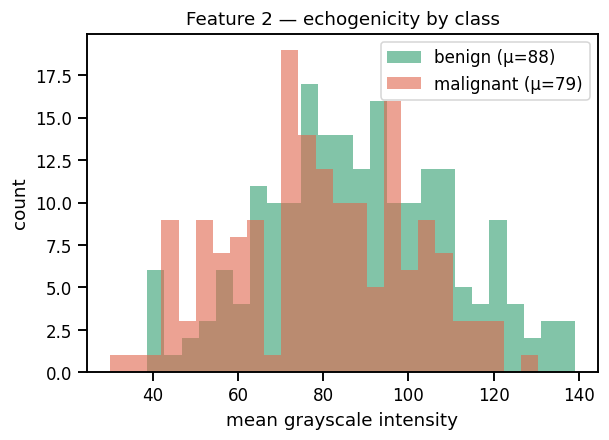

benign μ=88.4  vs  malignant μ=79.3


In [5]:
from PIL import Image
def mean_intensity(paths):
    return np.array([np.asarray(Image.open(p).convert('L')).mean() for p in paths])
ben = mean_intensity([p for p in train_paths if 'benign' in p][:200])
mal = mean_intensity([p for p in train_paths if 'malignant' in p][:200])
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(ben, bins=25, alpha=.6, label=f'benign (μ={ben.mean():.0f})', color='#2f9e6f')
ax.hist(mal, bins=25, alpha=.6, label=f'malignant (μ={mal.mean():.0f})', color='#e0654b')
ax.set_xlabel('mean grayscale intensity'); ax.set_ylabel('count'); ax.legend()
ax.set_title('Feature 2 — echogenicity by class'); plt.show()
print(f'benign μ={ben.mean():.1f}  vs  malignant μ={mal.mean():.1f}')

### Feature 3 · Raw image-size distribution
*What story does it tell?* Images come in **many sizes** (roughly 300–1000 px wide). The model needs a fixed input, so preprocessing must **standardise geometry** — every image is resized to 224×224. This is why the resize step is not optional.

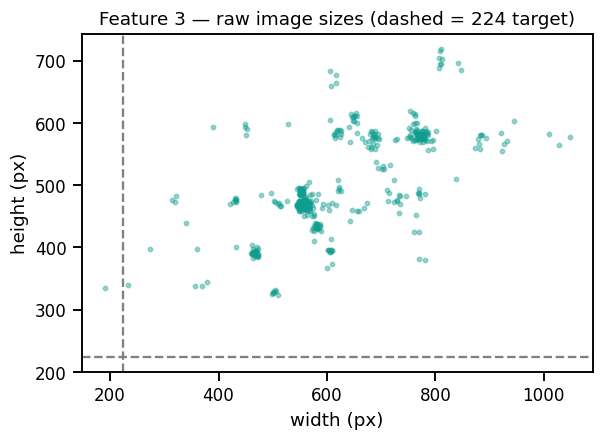

In [6]:
sizes = np.array([Image.open(p).size for p in train_paths])
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(sizes[:,0], sizes[:,1], s=8, alpha=.4, color='#0f9d8f')
ax.axvline(224, ls='--', c='grey'); ax.axhline(224, ls='--', c='grey')
ax.set_xlabel('width (px)'); ax.set_ylabel('height (px)')
ax.set_title('Feature 3 — raw image sizes (dashed = 224 target)'); plt.show()

### A look at the images

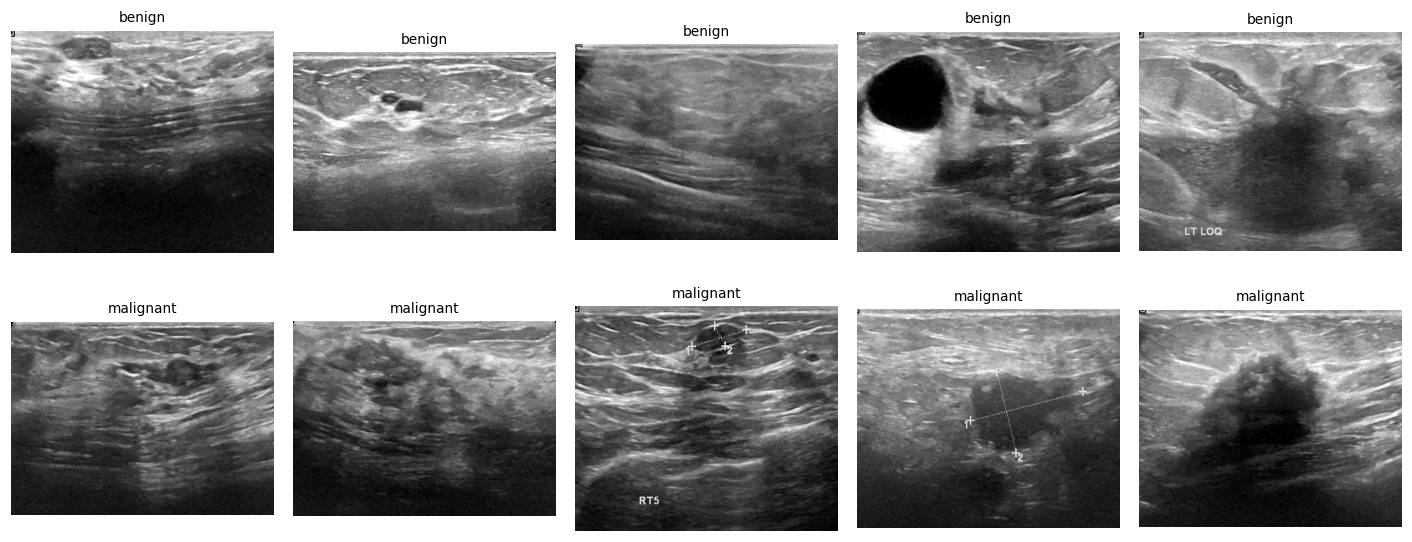

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for row, cls in enumerate(pp.CLASS_NAMES):
    cpaths = [p for p in train_paths if f'/{cls}/' in p or f'\\{cls}\\' in p][:5]
    for col, p in enumerate(cpaths):
        axes[row, col].imshow(Image.open(p), cmap='gray')
        axes[row, col].set_title(cls, fontsize=9); axes[row, col].axis('off')
plt.tight_layout(); plt.show()

## 4 · Preprocessing pipeline (`tf.data`)

`build_splits()` carves a stratified 15% validation slice from train and returns batched, prefetched `tf.data` datasets with on-the-fly augmentation (flip / rotate / zoom / contrast) on the training stream only.

In [8]:
train_ds, val_ds, test_ds, meta = pp.build_splits(DATA)
print('train/val/test =', meta['n_train'], meta['n_val'], meta['n_test'])
print('class weights  =', meta['class_weights'])
for xb, yb in train_ds.take(1):
    print('batch:', xb.shape, xb.numpy().min(), xb.numpy().max())

/Users/macbookpro/Documents/ALU/alu-machine_learning/MLOP-summative/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


train/val/test = 439 78 129
class weights  = {0: 1.0, 1: 2.091549295774648}
batch: (32, 224, 224, 3) 0.0 255.0


## 5 · Model creation — MobileNetV2 transfer learning

ImageNet-pretrained MobileNetV2 backbone → GlobalAveragePooling → Dropout(0.3) → Dense(1, sigmoid). Input is rescaled to [-1, 1] inside the model.

In [9]:
model, backbone = M.build_model(augment=True)
model.summary()

Model: "mobilenetv2_busi"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         


 augment (Sequential)        (None, 224, 224, 3)       0         


...

 dense (Dense)               (None, 1)                 1281      


Total params: 2259265 (8.62 MB)


Trainable params: 1281 (5.00 KB)


Non-trainable params: 2257984 (8.61 MB)


_________________________________________________________________


## 6 · Model training (two-phase)

Phase 1 trains the head with the backbone frozen; Phase 2 fine-tunes the top ~30 backbone layers at a low learning rate. Early stopping restores the best weights.

The full run is wrapped in `src.model.train()` (also used by the retraining endpoint). Set `TRAIN = True` to run it here; by default we load the already-trained artifact to keep the notebook fast and deterministic.

In [10]:
TRAIN = False   # set True to retrain from scratch (~5 min on CPU)
if TRAIN:
    metrics = M.train(data_dir=DATA, epochs_head=20, epochs_finetune=12)
else:
    import tensorflow as tf
    model = tf.keras.models.load_model(M.MODEL_PATH)
    print('Loaded trained model from', M.MODEL_PATH)

Loaded trained model from /Users/macbookpro/Documents/ALU/alu-machine_learning/MLOP-summative/models/mobilenet_busi.keras


## 7 · Model testing & evaluation

Every metric the assignment requires on the held-out test set: accuracy, precision, recall, F1, ROC-AUC, and the confusion matrix.

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
y_true = np.array(meta['test_labels']).astype(int)
y_prob = model.predict(test_ds, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
print(classification_report(y_true, y_pred, target_names=pp.CLASS_NAMES))
print('ROC-AUC:', round(roc_auc_score(y_true, y_prob), 3))

              precision    recall  f1-score   support

      benign       0.84      0.74      0.79        87
   malignant       0.57      0.71      0.63        42

    accuracy                           0.73       129
   macro avg       0.70      0.72      0.71       129
weighted avg       0.75      0.73      0.74       129

ROC-AUC: 0.867


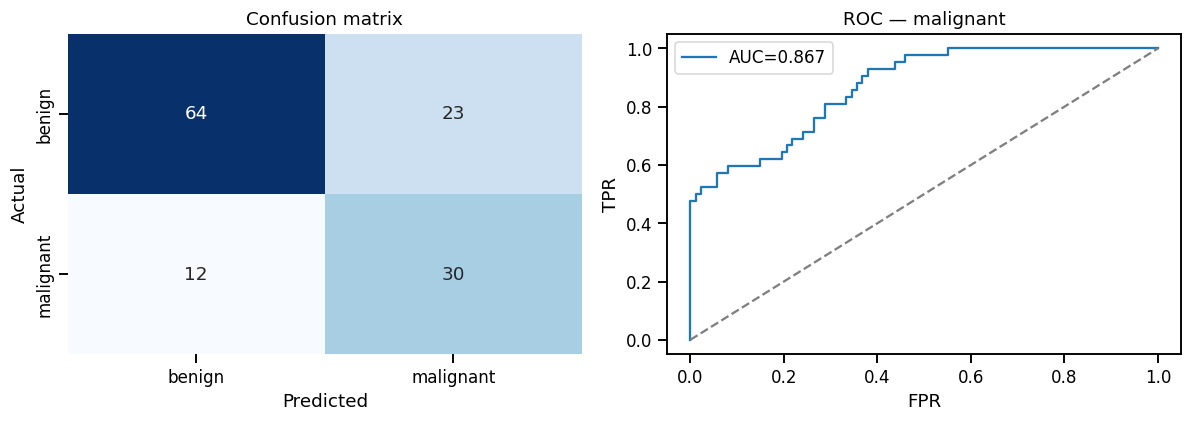

In [12]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=pp.CLASS_NAMES, yticklabels=pp.CLASS_NAMES, ax=ax[0])
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual'); ax[0].set_title('Confusion matrix')
fpr, tpr, _ = roc_curve(y_true, y_prob)
ax[1].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_true,y_prob):.3f}'); ax[1].plot([0,1],[0,1],'--',c='grey')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC — malignant'); ax[1].legend()
plt.tight_layout(); plt.show()

## 8 · Prediction function (single image)

`src.prediction.predict_image(bytes)` is exactly what the `/api/predict` endpoint calls. It resizes a single uploaded image through the same pipeline and returns the class + probabilities.

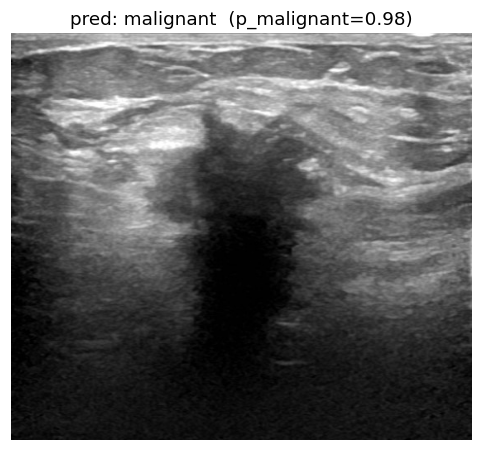

{'prediction': 'malignant',
 'predicted_index': 1,
 'probabilities': {'benign': 0.01881200075149536,
  'malignant': 0.9811879992485046},
 'malignant_probability': 0.9811879992485046,
 'confidence': 0.9811879992485046,
 'model_version': '20260727_105155'}

In [13]:
from src.prediction import predict_image
sample = [p for p in test_paths if 'malignant' in p][0]
result = predict_image(Path(sample).read_bytes())
plt.imshow(Image.open(sample), cmap='gray'); plt.axis('off')
plt.title(f"pred: {result['prediction']}  (p_malignant={result['malignant_probability']:.2f})")
plt.show()
result

## 9 · Retraining hook & deployment

Retraining reuses `M.train()`: the API stages user-uploaded images under `data/uploads/`, and when a retrain is triggered (button, or automatically past a threshold) those images are merged into `data/train/` and the model is retrained and hot-swapped — no redeploy needed.

The service (FastAPI + this model) is containerised (`Dockerfile`), load-balanced for the Locust flood test (`docker-compose.yml`), and deployed to Render (`render.yaml`). See the README.

---
### Summary
MobileNetV2 transfer learning reaches **ROC-AUC ≈ 0.87** on held-out BUSI test images, with recall on the malignant class prioritised via class weighting — the clinically important axis for a screening aid. The identical code path serves predictions and retrains in production.